In [1]:
!pip install cloudpickle --quiet

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, pandas as pd, numpy as np
import cloudpickle

model_path = '/content/drive/MyDrive/EEW_Models/EEWS_Himalayas.pkl'

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model file not found: {model_path}")

print("Loading model with cloudpickle:", model_path)
with open(model_path, 'rb') as f:
    model = cloudpickle.load(f)

print("Model loaded. Type:", type(model))

new_sample = {
    'PGA': 0.106792196389082,
    'PGD': 0.926489701115896,
    'CAV': 32.8691582444138,
    'Ia': 2.96209871131196,
    'Fp': 3.125,
    'Tsig': 1.38779728760517,
    'Sc': 0,
    'dir': 0
}
X_new = pd.DataFrame([new_sample])


for c in ['Sc', 'dir']:
    if c in X_new.columns:
        X_new[c] = X_new[c].astype(str)

print("Input for prediction:")
print(X_new)

# ---------- Predict ----------
y_pred = model.predict(X_new)

# Normalize to DataFrame
if isinstance(y_pred, np.ndarray):
    if hasattr(model, 'target_names'):
        cols = model.target_names
    else:
        cols = [f"t{i}" for i in range(y_pred.shape[1])]
    y_pred = pd.DataFrame(y_pred, columns=cols)

print("\nPredictions (first rows):")
print(y_pred.head())




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading model with cloudpickle: /content/drive/MyDrive/EEW_Models/EEWS_Himalayas.pkl
Model loaded. Type: <class '__main__.EEWS'>
Input for prediction:
        PGA      PGD        CAV        Ia     Fp      Tsig Sc dir
0  0.106792  0.92649  32.869158  2.962099  3.125  1.387797  0   0

Predictions (first rows):
     0.010    0.015     0.020     0.030     0.040     0.050     0.060  \
0  0.24741  0.24721  0.259493  0.259675  0.278399  0.297509  0.353866   

      0.075     0.090     0.100  ...     0.750    0.800     0.900    1.000  \
0  0.356533  0.468399  0.396191  ...  0.278804  0.34324  0.344135  0.23607   

      1.200     1.500     2.000     2.500     3.000     4.000  
0  0.138598  0.080963  0.079641  0.052027  0.039147  0.021846  

[1 rows x 27 columns]


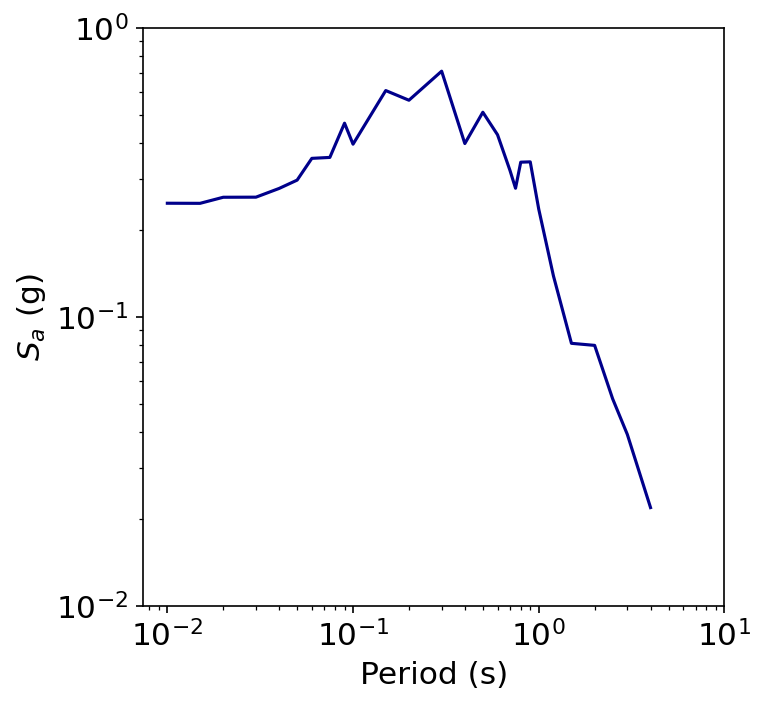

In [2]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

T = [0.01,
        0.015,   0.02,   0.03,   0.04,   0.05,   0.06,  0.075,   0.09,    0.1,
         0.15,    0.2,    0.3,    0.4,    0.5,    0.6,    0.7,   0.75,    0.8,
          0.9,      1,    1.2,    1.5,      2,    2.5,      3,      4]

figure(figsize=(5, 5), dpi=150)
fontsize= 15
plt.plot(T,y_pred.iloc[0,:].to_list(),color='darkblue')
plt.xlabel('Period (s)',fontsize=fontsize)
plt.ylabel('$S_a$ (g)',fontsize=fontsize)
plt.xscale('log')
plt.yscale('log')
plt.xticks([0.01,0.1,1,10])  # Chnage the axes ticks, fontsizes, colours etc.
plt.yticks([0.01,0.1,1])
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()